<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/deep-learning/CIFAR10_CNN_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN - CIFAR10 - Data Augmentation

## Loading the packages

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import utils

2026-04-06 11:36:47.394499: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-06 11:36:47.594803: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-06 11:36:47.595652: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-06 11:36:47.879129: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-06 11:36:49.187963: W tensorflow/compiler/tf

Define a function to plot some images from CIFAR and load the dataset.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


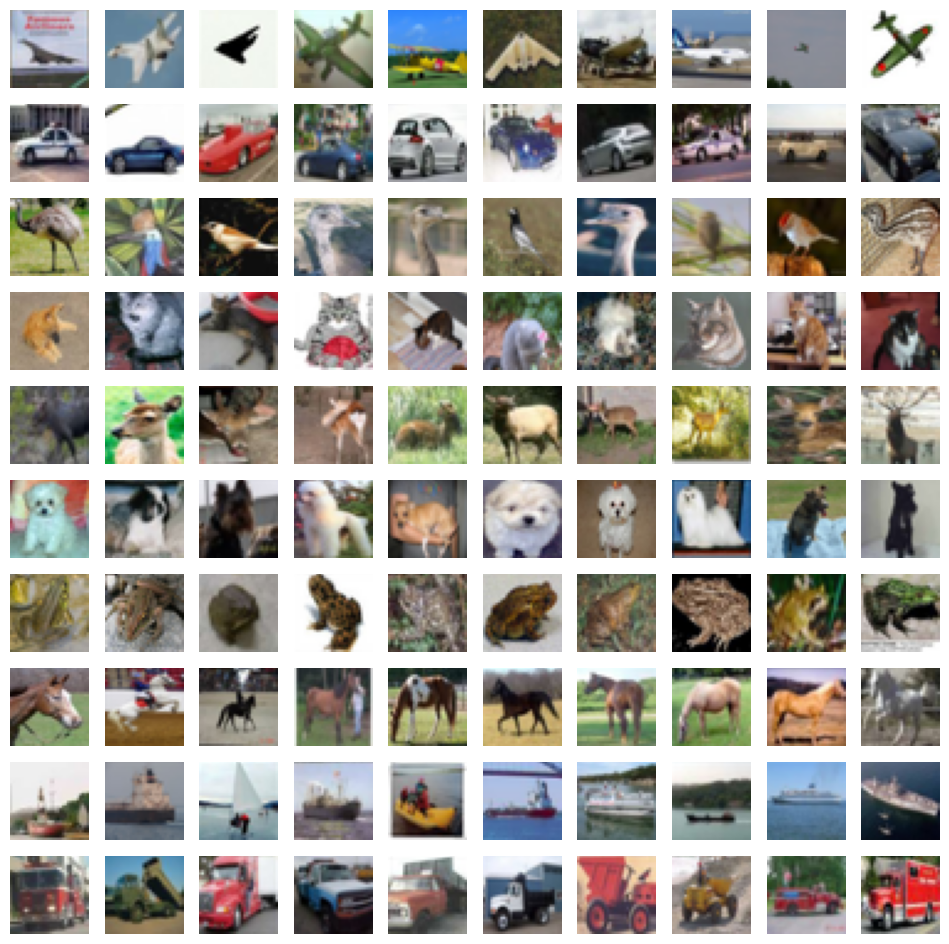

training input shape :  (50000, 32, 32, 3)
training output shape:  (50000, 1)
testing input shape  :  (10000, 32, 32, 3)
testing output shape :  (10000, 1)


In [ ]:
def show_imgs(X,y):
    plt.figure(1, figsize=(12,12))
    k = 0
    for i in range(0,10):
        for j in range(0,10):
            while y[k] != i: k += 1
            plt.subplot2grid((10,10),(i,j))
            plt.imshow(X[k])
            plt.axis('off')
            k += 1
    plt.show()

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
show_imgs(X_test, y_test)
print('training input shape : ', X_train.shape)
print('training output shape: ', y_train.shape)
print('testing input shape  : ', X_test.shape)
print('testing output shape : ', y_test.shape)

### Preprocessing data
After loading and splitting the data, we need to preprocess them by reshaping them into the shape the network expects and scaling them so that all values are in the \[0, 1\] interval.

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

50000 train samples
10000 test samples


The target values of the network are supposed to be 1-hot targets. Now the `y_train` is an array with scalar values as in `[5 0 4 1 ...]` and it should be a 1-hot array `Y_train` as in :

`[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]...]`

Note the change of capital letter in the `Y_train` to denote, per convention, an array with multiple dimensions.

In [ ]:
n_classes = 10
Y_train = utils.to_categorical(y_train, n_classes)
Y_test = utils.to_categorical(y_test, n_classes)
print(Y_train[:10])

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


## Define the network
The neural network will be a CNN. Follow the structure given in the exercise 1.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation, InputLayer
from tensorflow.keras.layers import Conv2D, MaxPooling2D


cnn = Sequential()
cnn.add(InputLayer(input_shape=(32,32,3)))
cnn.add(Conv2D(32, (3,3), padding = 'same'))
cnn.add(Activation('relu'))
cnn.add(Conv2D(32, (3,3), padding = 'same'))
cnn.add(Activation('relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Conv2D(32, (3,3), padding = 'same'))
cnn.add(Activation('relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Flatten())
cnn.add(Dense(256))
cnn.add(Activation('relu'))
cnn.add(Dense(n_classes))
cnn.add(Activation('softmax'))

cnn.summary()

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-04-06 11:52:17.615458: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-06 11:52:17.988241: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 546,506 (2.08 MB)

 Trainable params: 546,506 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and train the network

When compiling the model, we need to specify the loss function, the optimizer and the metrics we want to track during the training. In Keras, we need to call the methods `compile()` and `fit()`. We will train through E epochs, using batches of size B, as specified in the exercise 1.

- The `categorical_crossentropy` loss is relevant for multiclass, single-label classification problem. Categorical is used because there are 10 classes to predict from. If there were 2 classes, we would have used `binary_crossentropy`.
- The `adam` optimizer is an improvement over SGD(Stochastic Gradient Descent). The optimizer is defining the update rule for the weights of the neurons during backpropagation gradients.

In [ ]:
cnn.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics=['accuracy'])
log = cnn.fit(X_train, Y_train, epochs=10, batch_size=64, validation_data=(X_test, Y_test))

Epoch 1/10


2026-04-06 11:54:02.184715: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.7230 - loss: 0.7930 - val_accuracy: 0.7044 - val_loss: 0.8429
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.7680 - loss: 0.6662 - val_accuracy: 0.7219 - val_loss: 0.7912
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.8055 - loss: 0.5553 - val_accuracy: 0.7370 - val_loss: 0.7826
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.8393 - loss: 0.4576 - val_accuracy: 0.7198 - val_loss: 0.8821
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.8730 - loss: 0.3626 - val_accuracy: 0.7299 - val_loss: 0.8833
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9018 - loss: 0.2802 - val_accuracy: 0.7221 - val_loss: 0.9990
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9286 - loss: 0.2064 - val_accuracy: 0.7206 - val_loss: 1.1424
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.9477 - loss: 0.1536 - val_accurac

## Evaluate the network

We can do this at three levels: (1) plot of the loss during the training phase, (2) overall accuracy evaluation on test set and (3) per class evaluation with confusion matrix on test set.

### Loss and accuracy evolution during training
This can be done first looking at the history of the training (output of the `fit()` function).

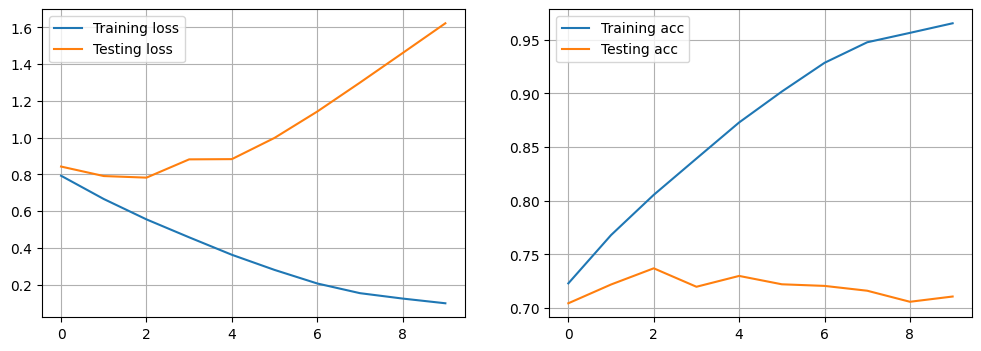

In [ ]:
f = plt.figure(figsize=(12,4))
ax1 = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax1.plot(log.history['loss'], label='Training loss')
ax1.plot(log.history['val_loss'], label='Testing loss')
ax1.legend()
ax1.grid()
ax2.plot(log.history['accuracy'], label='Training acc')
ax2.plot(log.history['val_accuracy'], label='Testing acc')
ax2.legend()
ax2.grid()

### Model evaluation
We can compute the overall performance on test set calling the `evaluate()` function on the model. The function returns the loss and the metrics used to compile the models.

In [ ]:
loss_test, metric_test = cnn.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

Test loss: 1.6229256391525269
Test accuracy: 0.7106999754905701


### Confusion matrix
We can call the `predict()` function to get the predicted classes. The output array of ground truth `y_test` and the predicted classes can then be fed to the `confusion_matrix()` function of [sklearn metrics package](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix).

In [ ]:
from sklearn.metrics import confusion_matrix

pred = cnn.predict(X_test, verbose=0)
pred = np.argmax(pred, axis=-1)
confusion_matrix(y_test, pred)

array([[802,  20,  30,  26,  11,   4,   7,  12,  65,  23],
       [ 30, 809,   7,  11,   4,   5,   7,   3,  37,  87],
       [ 96,   8, 607,  83,  65,  50,  31,  33,  18,   9],
       [ 38,  11,  70, 555,  48, 160,  30,  56,  19,  13],
       [ 27,   4,  92,  76, 607,  49,  34,  94,  12,   5],
       [ 15,   5,  49, 212,  27, 596,   7,  70,  13,   6],
       [  8,   3,  67,  95,  32,  45, 717,  16,  13,   4],
       [ 21,   7,  47,  31,  41,  47,   2, 776,  11,  17],
       [ 66,  20,   8,  14,  11,   5,   4,   3, 854,  15],
       [ 37,  83,   9,  20,   4,   3,   3,  18,  39, 784]])

## **1. Data Augmentation**

Overfitting can be caused by having networks with too many parameters that are trained on too few samples. Through training, the model learns *by hart* and generalizes poorly.

**Data augmentation** takes the approach of generating artificially more training data from existing training samples. For images, data augmentation is performed via a number of random transformations that yield believable-looking images. The goal is that at training time, the model will not see the exact same picture twice. This helps expose the model to more aspects of the data and generalize better.

In Keras, this can be done by configuring a number of random transformations to be performed on the images read by the ```ImageDataGenerator``` instance.

- rotation_range is a value in degrees (0–180), a range within which to randomly rotate pictures.
- width_shift and height_shift are ranges (as a fraction of total width or height) within which to randomly translate pictures vertically or horizontally.
- shear_range is for randomly applying shearing transformations.
- zoom_range is for randomly zooming inside pictures.

Don't forget to reset your network (by defining it again). You need then to compile the network and train it. The call to the `fit()` function has to be replaced by a call to `fit_generator()` and using the data flow defined above.

- **V1**:

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data augmentation pipelines for train set
datagen = ImageDataGenerator(rotation_range = 8, width_shift_range = 0.08, shear_range = 0.3, height_shift_range = 0.08, zoom_range = 0.08)

train_batches = datagen.flow(X_train, Y_train, batch_size = 128)
valide_batches = datagen.flow(X_test, Y_test, batch_size=128)

log = cnn.fit(train_batches, steps_per_epoch = 600000//128+1, verbose = 1, epochs = 20, validation_data = (X_test, Y_test))

score1 = cnn.evaluate(X_test, Y_test, verbose=0)
print('test loss : ', score1[0])
print('test accuracy : ', score1[1])

Epoch 1/20
 391/4688 ━━━━━━━━━━━━━━━━━━━━ 8:04 113ms/step - accuracy: 0.7554 - loss: 0.7550

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4688/4688 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.7672 - loss: 0.6848 - val_accuracy: 0.7220 - val_loss: 0.9550
Epoch 2/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.7917 - loss: 0.5901 - val_accuracy: 0.7315 - val_loss: 0.8811
Epoch 3/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - accuracy: 0.8010 - loss: 0.5610 - val_accuracy: 0.7469 - val_loss: 0.8559
Epoch 4/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - accuracy: 0.8100 - loss: 0.5406 - val_accuracy: 0.7478 - val_loss: 0.8392
Epoch 5/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.8162 - loss: 0.5239 - val_accuracy: 0.7497 - val_loss: 0.8211
Epoch 6/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - accuracy: 0.8202 - loss: 0.5059 - val_accuracy: 0.7418 - val_loss: 0.8727
Epoch 7/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.8232 - loss: 0.4939 - val_accuracy: 0.7515 - val_loss: 0.8343
Epoch 8/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - accuracy: 0.8326 - loss: 0.475

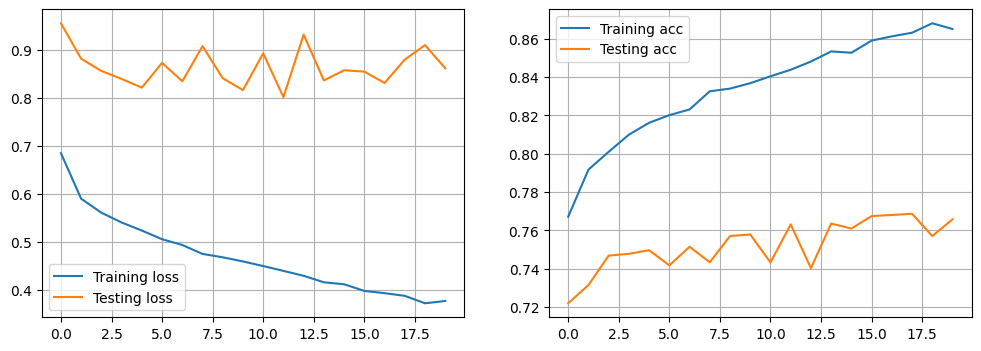

In [ ]:
f = plt.figure(figsize=(12,4))
ax1 = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax1.plot(log.history['loss'], label='Training loss')
ax1.plot(log.history['val_loss'], label='Testing loss')
ax1.legend()
ax1.grid()
ax2.plot(log.history['accuracy'], label='Training acc')
ax2.plot(log.history['val_accuracy'], label='Testing acc')
ax2.legend()
ax2.grid()

In [ ]:
loss_test, metric_test = cnn.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

Test loss: 0.8613905310630798
Test accuracy: 0.7657999992370605


- **V2**

In [ ]:
datagen = ImageDataGenerator(rotation_range = 90, width_shift_range = 0.1, shear_range = 0.5, height_shift_range = 0.1, zoom_range = 0.1)

train_batches = datagen.flow(X_train, Y_train, batch_size = 128)
valide_batches = datagen.flow(X_test, Y_test, batch_size=128)

log = cnn.fit(train_batches, steps_per_epoch = 600000//128+1, verbose = 1, epochs = 20, validation_data = (X_test, Y_test))

score1 = cnn.evaluate(X_test, Y_test, verbose=0)
print('test loss : ', score1[0])
print('test accuracy : ', score1[1])

Epoch 1/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - accuracy: 0.5410 - loss: 1.3274 - val_accuracy: 0.6735 - val_loss: 0.9811
Epoch 2/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.5903 - loss: 1.1677 - val_accuracy: 0.6826 - val_loss: 0.9560
Epoch 3/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.6069 - loss: 1.1145 - val_accuracy: 0.6678 - val_loss: 1.0033
Epoch 4/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.6213 - loss: 1.0795 - val_accuracy: 0.6874 - val_loss: 0.9393
Epoch 5/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.6261 - loss: 1.0597 - val_accuracy: 0.6912 - val_loss: 0.9155
Epoch 6/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.6391 - loss: 1.0246 - val_accuracy: 0.6896 - val_loss: 0.9307
Epoch 7/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - accuracy: 0.6428 - loss: 1.0166 - val_accuracy: 0.7003 - val_loss: 0.9101
Epoch 8/20
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.6531 - loss: 

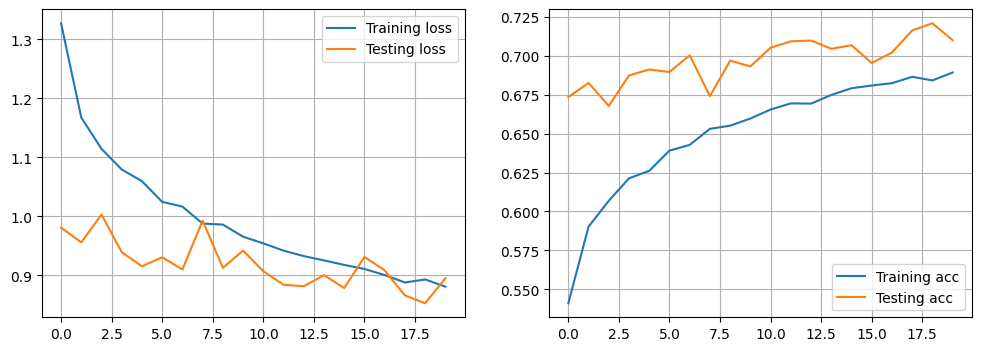

In [ ]:
f = plt.figure(figsize=(12,4))
ax1 = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax1.plot(log.history['loss'], label='Training loss')
ax1.plot(log.history['val_loss'], label='Testing loss')
ax1.legend()
ax1.grid()
ax2.plot(log.history['accuracy'], label='Training acc')
ax2.plot(log.history['val_accuracy'], label='Testing acc')
ax2.legend()
ax2.grid()

In [ ]:
loss_test, metric_test = cnn.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss_test)
print('Test accuracy:', metric_test)

Test loss: 0.8950091600418091
Test accuracy: 0.7099999785423279


### Table of results

Describe your data augmentation strategies here.

| CNN | Architecture description | Acc. train | Acc. test |
|-----|--------------------------|------------|-----------|
|  No DA | CONV(32F,same)-RELU-CONV(32F,same)-RELU-MAXP(2)-CONV(32F,same)-RELU-MAXP(2)-DENSE | 97%  | 71% |
|  With DA v1 | CONV(32F,same)-RELU-CONV(32F,same)-RELU-MAXP(2)-CONV(32F,same)-RELU-MAXP(2)-DENSE | 87%  | 76% |
|  With DA v2 | CONV(32F,same)-RELU-CONV(32F,same)-RELU-MAXP(2)-CONV(32F,same)-RELU-MAXP(2)-DENSE | 68%  | 71% |
| ... | | | |

> Data augmentation lust be chosen wisely to ensure an overal good performance.

## **2. Visualizing What My Model Learns**

It’s often said that deep-learning models are “black boxes”: learning representations that are difficult to extract and present in a human-readable form. Although this is partially true for certain types of deep-learning models, it’s definitely not true for convnets. The representations learned by convnets are highly amenable to visualization, in large part because they’re representations of visual concepts.
Here we attempt to visualize the intermediate CNN outputs (intermediate activations). Visualizing intermediate activations consists of displaying the feature maps that are output by various convolution and pooling layers in a network, given a certain input (the output of a layer is often called its activation, the output of the activation function). This gives a view into how an input is decomposed into the different filters learned by the network.
We want to visualize feature maps with three dimensions: width, height, and depth (channels). Each channel encodes relatively independent features, so the proper way to visualize these feature maps is by independently plotting the contents of every channel as a 2D image.

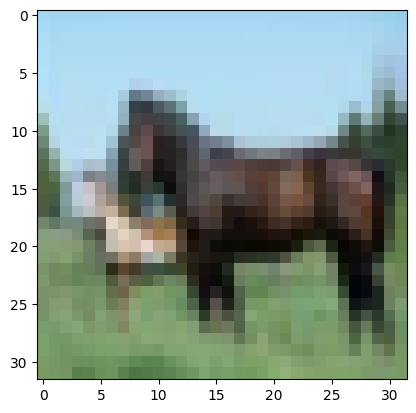

In [ ]:
# visualize image number 12
test_im1 = X_train[12]
plt.imshow(test_im1)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


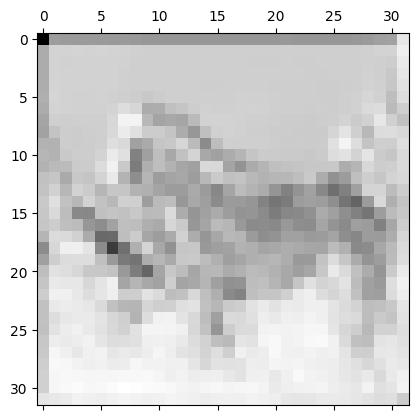

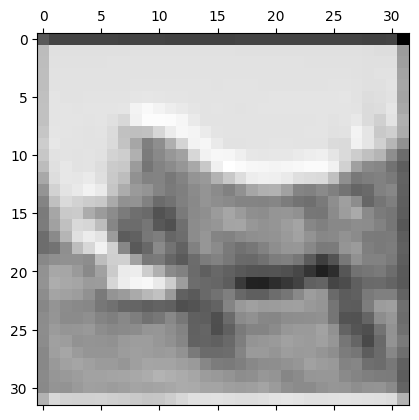

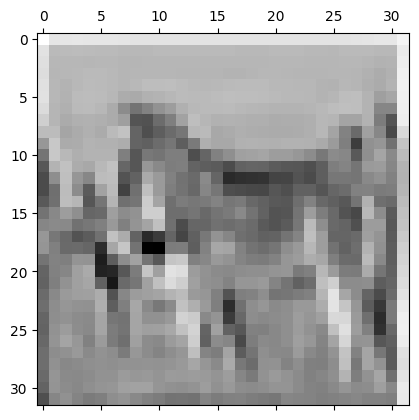

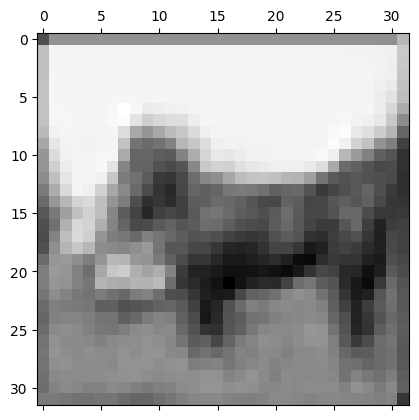

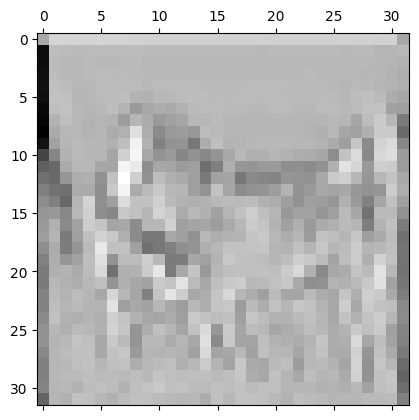

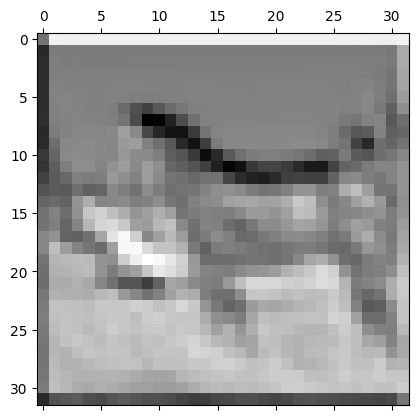

In [ ]:
#  Now implement a code to visualise all the filters at a given layer.
#  Hints : use subplots to have a grid of images, use for loops to avoid code repetition.
from tensorflow.keras import models

layer_input = cnn.layers[0].input
layer_1st_conv = cnn.layers[0].output

activation_model = models.Model(inputs=layer_input, outputs=layer_1st_conv)

test_im1 = test_im1.reshape(1, 32, 32, 3)

first_layer_activation =activation_model.predict(test_im1)

for i in range(6):
    plt.matshow(first_layer_activation[0, :, :, i], cmap='Greys')
#  Use the code shown in-class to perform this exercise

> We can observe that the different activation maps catch the general structure of the animal. This is this stucture that we allow to correctly classify this animal as a horse.

## **3. Optional : Deeper Models**
Let's play here with a deeper CNN model on CIFAR10 using a structure inspired by VGGNet: [[Conv2D $\rightarrow$ relu $\rightarrow$ BN]*3 $\rightarrow$ MaxPool2D $\rightarrow$ Dropout]*4 $\rightarrow$ Flatten $\rightarrow$ Dense $\rightarrow$ Dropout $\rightarrow$ Out.
In this structure, BN means Batch Normalisation. You can try different options but a configuration with blocks of 64 filters of size 3 with same padding and stride 1, max pooling of size 2 and stride 2, dropouts of 0.2 and a dense layer of 256 neurons should bring your performance around 80-85\% on CIFAR10.

You probably  need to use a GPU to train such networks and play with different settings. You may use freely available GPUs on Colab, see https://colab.research.google.com/
To activate the gpu on Colab, go to Edit > Notebook settings and select GPU.}. Report your best performances with and without data augmentation as in Exercise 1. What are your observations.

In [ ]:
from tensorflow.keras import models, layers, optimizers, callbacks

def conv_bn_relu(x, filters=64, kernel=3):
    x = layers.Conv2D(filters, kernel, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def build_model(input_shape=(32, 32, 3), num_classes=10, filters=64, dense_units=256, dropout=0.2):
    inp = layers.Input(shape=input_shape)
    x = inp

    for _ in range(4):
        x = conv_bn_relu(x, filters)
        x = conv_bn_relu(x, filters)
        x = conv_bn_relu(x, filters)
        x = layers.MaxPooling2D(pool_size=2, strides=2)(x)
        x = layers.Dropout(dropout)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out)

model = build_model()
model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             

 Total params: 478,666 (1.83 MB)

 Trainable params: 477,130 (1.82 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
log = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=20, batch_size=64)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 291s 365ms/step - accuracy: 0.4657 - loss: 1.4513 - val_accuracy: 0.4287 - val_loss: 1.6952
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 278s 355ms/step - accuracy: 0.6550 - loss: 0.9836 - val_accuracy: 0.5503 - val_loss: 1.3678
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 275s 352ms/step - accuracy: 0.7211 - loss: 0.8033 - val_accuracy: 0.6748 - val_loss: 0.9532
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 269s 344ms/step - accuracy: 0.7617 - loss: 0.6955 - val_accuracy: 0.7475 - val_loss: 0.7310
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 277s 354ms/step - accuracy: 0.7897 - loss: 0.6201 - val_accuracy: 0.7634 - val_loss: 0.7104
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 278s 356ms/step - accuracy: 0.8054 - loss: 0.5707 - val_accuracy: 0.7713 - val_loss: 0.6911
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 285s 364ms/step - accuracy: 0.8235 - loss: 0.5197 - val_accuracy: 0.7597 - val_loss: 0.7161
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 282s 361ms/step - accuracy: 0.8390 -


Test accuracy: 0.8621


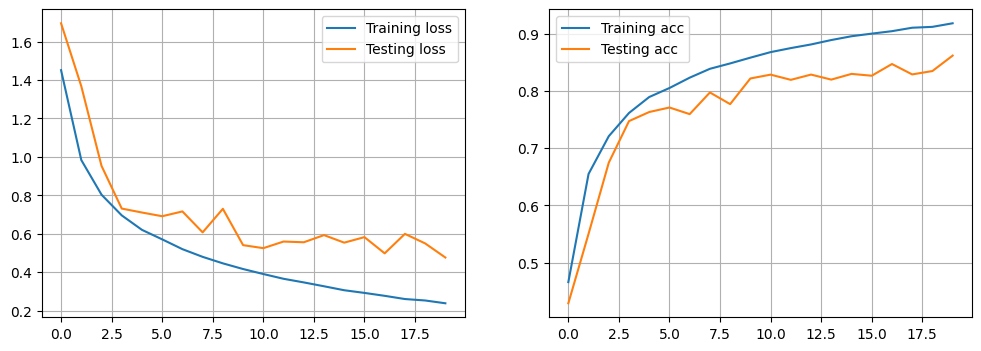

In [ ]:
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f'\nTest accuracy: {acc:.4f}')

f = plt.figure(figsize=(12,4))
ax1 = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax1.plot(log.history['loss'], label='Training loss')
ax1.plot(log.history['val_loss'], label='Testing loss')
ax1.legend()
ax1.grid()
ax2.plot(log.history['accuracy'], label='Training acc')
ax2.plot(log.history['val_accuracy'], label='Testing acc')
ax2.legend()
ax2.grid()

> We have reached 86% of accuracy with this model that is inspired from VGGNet.

## **4. Analysis of a Deep Architecture**

The analysis of the deep CNN architectures we did in the class covered the evolution observed on the ImageNet LSVRC competition until 2017. New architectures were introduced after that, such as for exemple the **Inception-v4**, **XCeption**, **EfficientNet**, etc. Other strategies based on deep CNNs have also emerged for other tasks such as *image detection* (finding bounding boxes around the objects of interest), such as **Yolo** (v1 to v6).


CHOSEN ARCHITECTURE : **YOLO**

- main reference explaining its architecture : Redmon, Joseph, Santosh Divvala, Ross Girshick, et Ali Farhadi. « **You Only Look Once: Unified, Real-Time Object Detection** ». arXiv:1506.02640. Prépublication, arXiv, 9 mai 2016. https://doi.org/10.48550/arXiv.1506.02640.

- YOLO in a nutshell :
    - "You Only Look Once" at an image to predict what objects are present and where they are
    
    - A single convolutional network simultaneously predicts multiple bounding boxes and class probabilities for those boxes. YOLO trains on full images and directly optimizes detection performance (frame detection is treated as a regression problem : no need for a complex pipeline)
    - The whole detection pipeline is a signal network end-to-end optimizable, while other models as R-CNN have individual component that must be trained separately.
    - YOLO can processes images in real-time at 45 frames per second, with no batch processing.
    
    - Compared to state-of-the-art detection systems (e.g. the models presented in class), YOLO makes more localization errors but is less likely to predict false positives on background.
    - Unlike sliding window and region proposal-based techniques, YOLO sees the entire image during training and test time so it implicitly encodes contextual information about classes as well as their appearance.
   
    - Since YOLO is highly generalizable it is less likely to break down when applied to new domains or unexpected inputs
    - 24 convolutional layers followed by 2 fully connected layers. Alternating 1 × 1 convolutional layers reduce the features space from preceding layers.
    
    - **VGG** is more accurate but also significantly slower than YOLO.
    - Convolutional layers are pretrained on the ImageNet 1000-class competition dataset. For pretraining,  the first 20 convolutional layers are used followed by an average-pooling layer and a fully connected layer. Training last approximately a week and achieve a single crop top-5 accuracy of 88% on the ImageNet 2012 validation set, comparable to the **GoogLeNet** models.
    - Throughout training, a batch size of 64, a momentum of 0.9 and a decay of 0.0005 were used.

## **5. Optional: Review Questions**
sources :
- https://fiveable.me/deep-learning-systems/unit-7/feature-extraction-hierarchical-representations-cnns/study-guide/2xbggOUYOkuvAb3S

a) Explain the notion of hierarchical features with CNNs.
> Feature hierarchy in CNN allows to build progressively complex representations. Firstly, with the early layers, we detect the **low**-level features (color, egdes...). Then wan can catch the **mid**-level features (shapes, objects...) with the intermediate layers. Finaly the **high**-level features (structure, scene compositions...) are detected thanks to the deeper layers.


b) Explain 2 strategies to visualise the modelling taking place in CNNs.
> We can visualize the **activation maps** as in the exercise 2 of this pratical work. The multiple filter are shown for a given conv layer, allowing us to better understand the structures or edges catched by the model.
> We can also fint the **input images that maximise the activation** of a given neuron. We start with a random image and apply the forward then the backward passes to extract the gradient. This gradient will tells us how to change the pixel value to increase the activation of the neuron.


c) What do we try to fight when using data augmentation ?
> Overfitting can be reduced with data augmenatation. This techniques diversify our data set to have more examples to see for the training.


d) What are the different implementation strategies for data augmentation ?
> We can use the pre-augmentation : we firstlu create our "new" images before training the model.


> We can also use the online augmentation where we configure a pipeline which will apply transformation to the images.



e) Can we say that data augmentation is a form of regularization allowing to limit overfitting ?
> Yes because data augmentation can limit or reduce the overfitting, as a regularization technique. However, regularization focus on the model (batchnorm, dropout, L2...), while data augmentation focus on the dataset and its number of examples available for the training and testing.


f ) Explain the main differences for the deep architectures seen in class : AlexNet, VGGNet, GoogLeNet, ResNet. What were their intuitions when putting together such architectures ?
> AlexNet was the proof that stacking a lot of layer will improve the performance of the CNN. The main intuition was to train deeper and deeper neural network to show the benefit of the depth. AlexNet shows that ReLU activation or even Dropout are key techniques to enhance the precision of the results and to accelerate the runing time.

> VGGNet highlight the fact that if we standardize the layers (e.g. always two stacked 3x3 conv layers) we can reach very good performance while avoid a complexity about the diversity of types of layers. Howerver, due to the great perfomance of VGGNet, the curse of dimensionnality and the problem of the vanishing gradient were discover.

> GoogleNet decided to focus on the width instead of the depth. Indeed, GoogleNet use 1x1, 3x3 and 5x5 conv layers in parallel and then concatenate the results, instead of chaining deeper conv layers. This is the idea of "a network in the network". The model don't use fully connected layers and 1x1 conv layers to reduce drastically the number of parameter.

> ResNet invented the identity shortcut added to the output of different layers that had calculates residual of the full mapping. ResNet use bottleneck layers 1x1 to reduce the number of operations and parameters, as GoogleNet